# INFERENCE STATISTICS AND HYPOTHESIS TESTING

## SUY DIỄN THỐNG KÊ VÀ GIẢ THUYẾT THỬ NGHIỆM

---

## ESTIMATION VERSUS INFERENCE

- Estimation is the application of an algorithm, for example taking an average : 

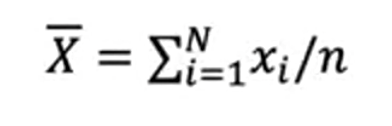

- Inference : involves putting an accuracy on the estimate 

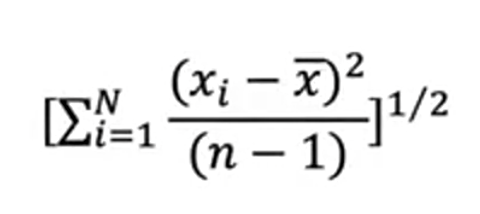

- Machine learning and statistics inference are similar 

-> In both cases, we're using data to learn/infer qualities of a distribution that generated the data (often termed the data-generating process)

- We may care either about the whole distribution or just features (e.g. mean)

- Machine learning applications that focus on understanding parameters and individual effects involve more tools from statistical inference (some applications are focus only on result)

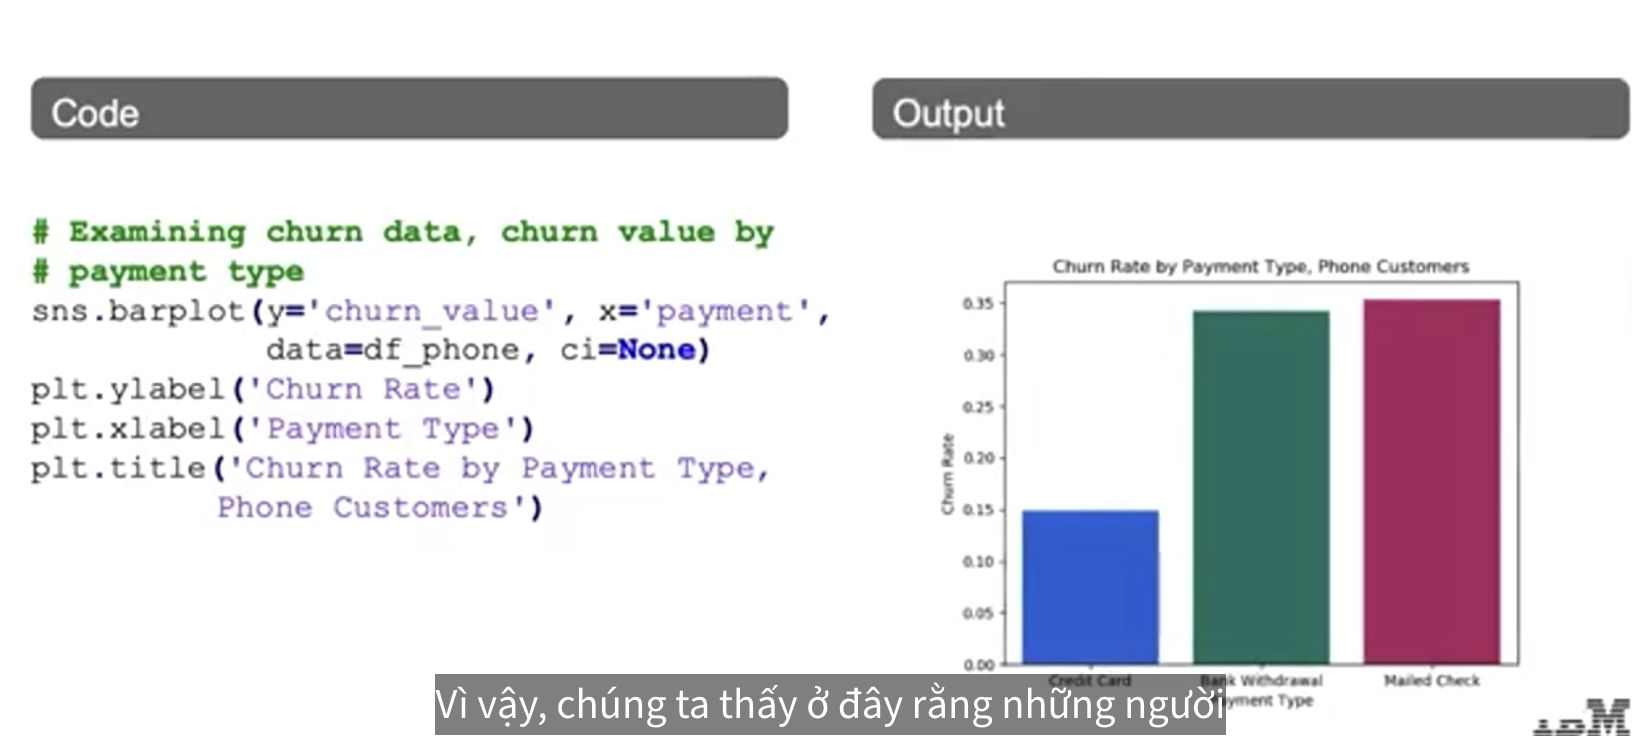

---

`sns.pairplot(pairplot, hue='churn_value')` : 

Tạo một lưới các biểu đồ phân tán (scatter plots) cho từng cặp biến để quan sát mối quan hệ tương quan chéo giữa chúng

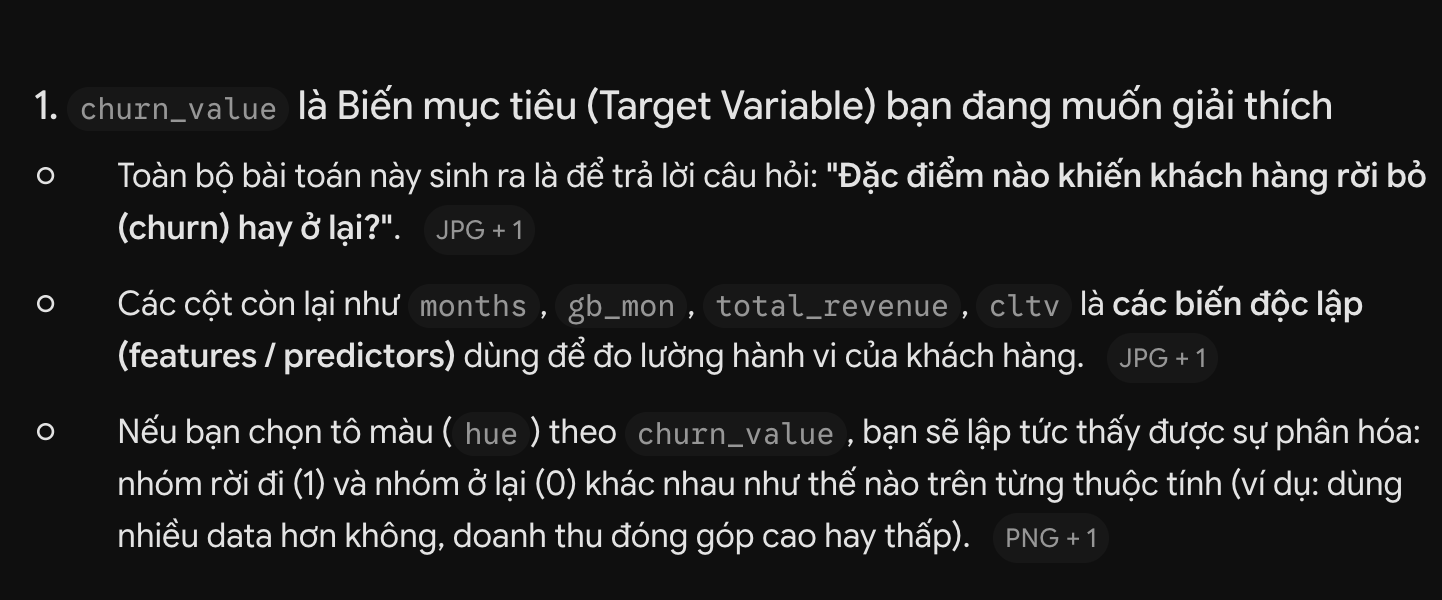

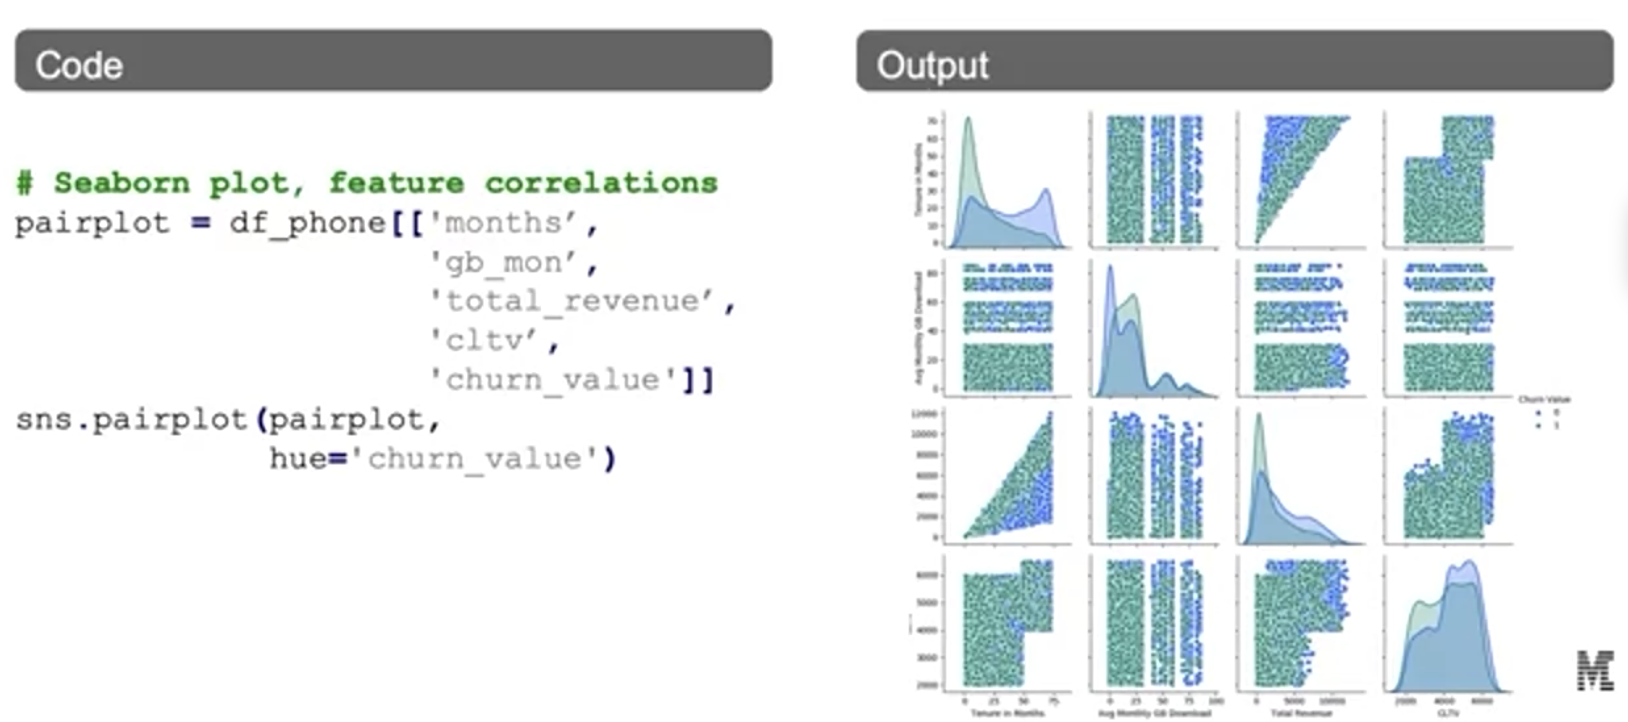

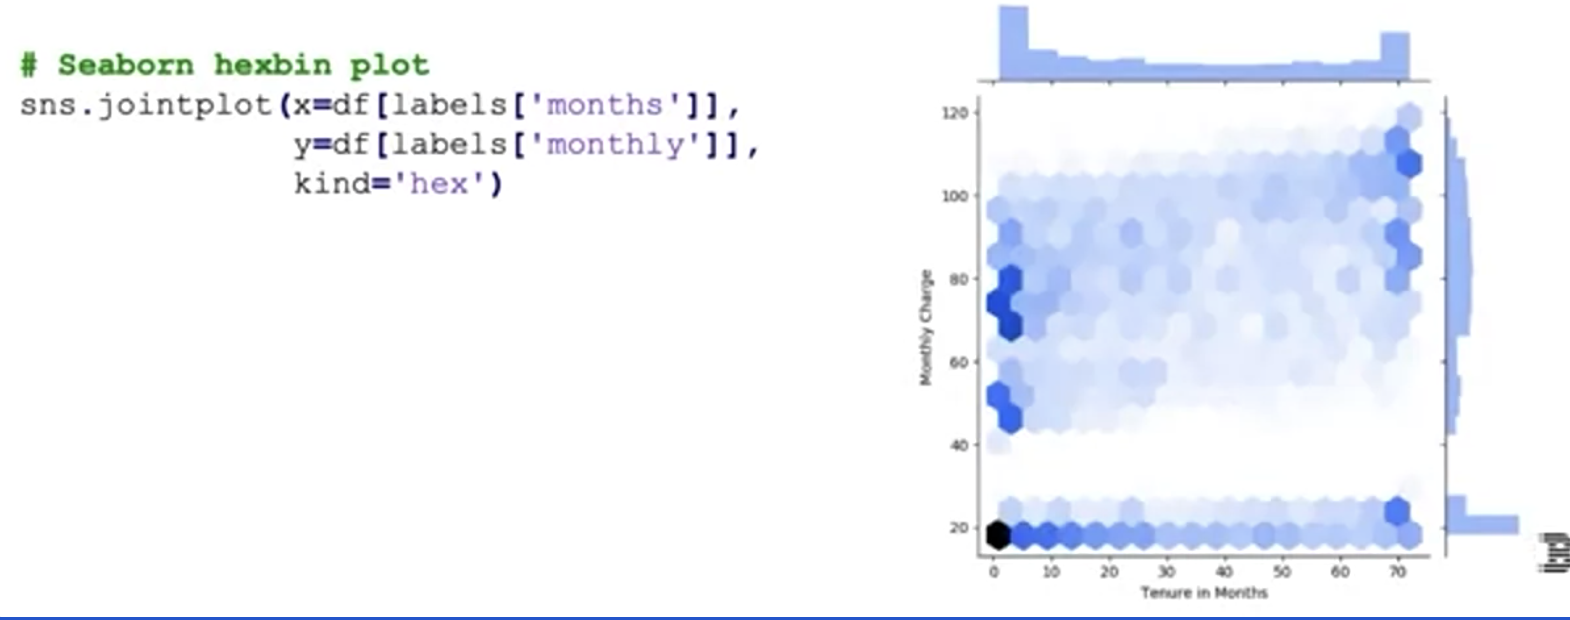

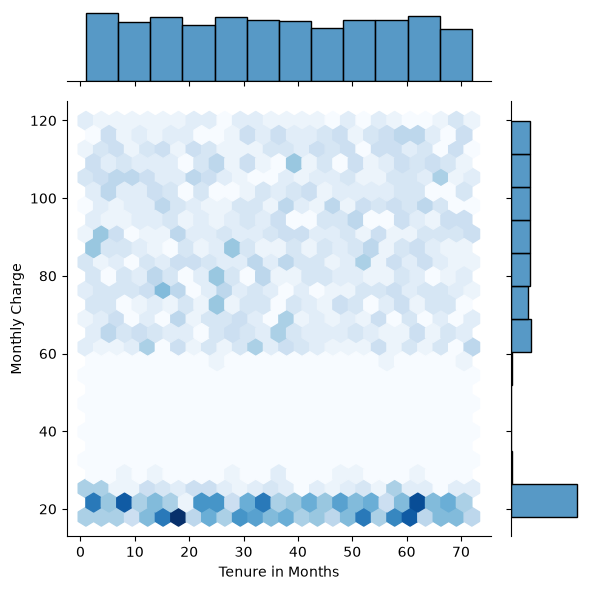

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Tạo tập dữ liệu giả lập mô phỏng hình ảnh trong slide
np.random.seed(42)
n_samples = 1500

# Tạo cột tenure (tháng) từ 1 đến 72 tháng
months = np.random.randint(1, 73, size=n_samples)

# Tạo cột monthly_charges (cước phí) dao động từ 20 đến 120
# Cố tình gom cụm ở mức cước ~20 và các mốc cước cao để giống hình slide
charges_low = np.random.normal(loc=20, scale=3, size=n_samples // 3)
charges_high = np.random.uniform(60, 120, size=n_samples - (n_samples // 3))
monthly_charges = np.clip(np.concatenate([charges_low, charges_high]), 18, 125)

# Đưa vào DataFrame
df = pd.DataFrame({
    'tenure_months': months,
    'monthly_charges': monthly_charges
})

# Dictionary ánh xạ nhãn giống như trong slide
labels = {
    'months': 'tenure_months',
    'monthly': 'monthly_charges'
}

# 2. Vẽ biểu đồ Seaborn Hexbin Jointplot
# gridsize điều chỉnh độ to/nhỏ của các ô lục giác
grid = sns.jointplot(
    x=df[labels['months']], 
    y=df[labels['monthly']], 
    kind='hex',
    cmap='Blues',
    gridsize=25
)

# Đặt lại tên trục cho khớp với slide
grid.set_axis_labels('Tenure in Months', 'Monthly Charge')
plt.tight_layout()
plt.show()

Đọc Hexbin là đi **"tìm chỗ nào màu đậm nhất"** và chỗ nào bị màu trắng 

---

## PARAMETRIC VS NON-PARAMETRIC

tham so voi khong tham so

If interence is about trying to find out the Data - Generating Process (DGP), then we can say that a stastical model (of the data) is a set of possible distributions or maybe even regression

A parametric model is a particular type of statistical model : it's also a set of distributions or regression, but they have a finite number of parameters

- Inference (Suy diễn thống kê): Bản chất là việc đi tìm cơ chế hoặc quy luật tự nhiên đã tạo ra tập dữ liệu quan sát được (gọi là Data-Generating Process - DGP). 

- Statistical model (Mô hình thống kê): Vì ta không biết chính xác 100% DGP thực tế trông như thế nào, ta tạo ra một tập hợp các phân phối xác suất khả dĩ (a set of possible distributions) 

    hoặc các dạng hàm hồi quy khả dĩ để xấp xỉ nó. Mô hình đóng vai trò là một "không gian giả định" chứa các quy luật có thể sinh ra dữ liệu.

- Khái niệm cốt lõi: Là một dạng mô hình thống kê đặc biệt, trong đó cấu trúc phân phối hoặc hàm hồi quy được xác định hoàn toàn bởi một số lượng tham số hữu hạn và cố định (finite number of parameters).

- Ít đưa ra giả định trước (Make fewer assumptions): Khác với phương pháp tham số (vốn bắt buộc dữ liệu phải tuân theo một khuôn mẫu toán học cứng nhắc nào đó), thống kê phi tham số đặt ra rất ít điều kiện ràng buộc đối với dữ liệu đầu vào.   


- Không ép dữ liệu vào bất kỳ phân phối cụ thể nào (Distribution-free inference): Ta không mặc định trước rằng dữ liệu phải có phân phối chuẩn (Gaussian/hình chuông), phân phối Poisson hay nhị thức. Mô hình sẽ để chính dữ liệu tự lên tiếng và tự định hình phân phối của nó. 

## PARAMETRIC MODELS

- A parametric models is a particular type of statistical model : 

    (it's also a set of distribution or regressions, but they hav a finite number or paremeters)

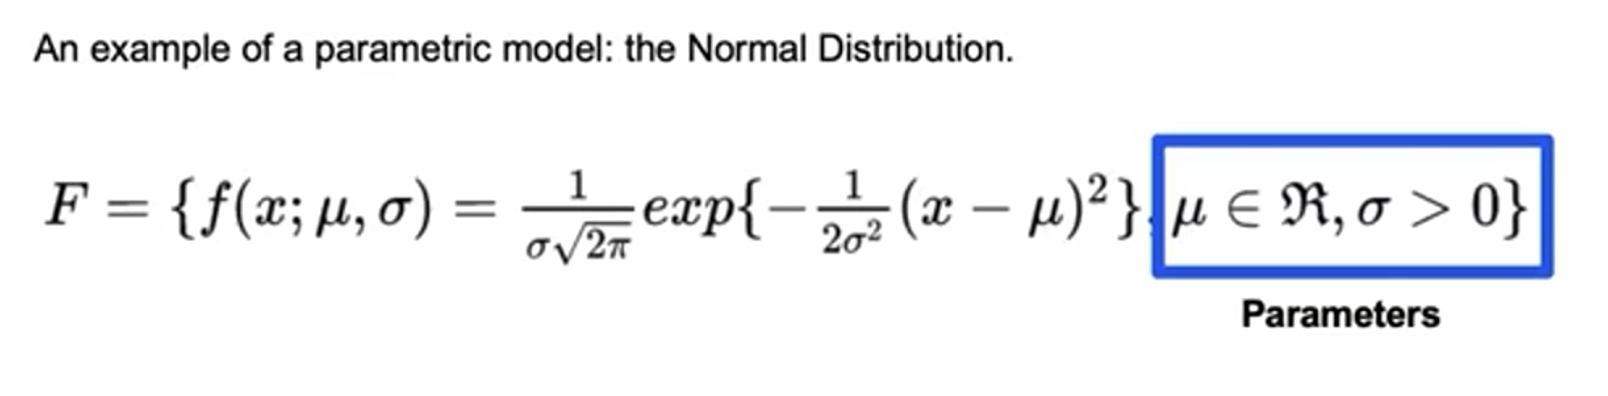

That means, in every database, if we find the mean and the standard deviation : we can totally find out the picture of how data is distributed

For example : 

We have a dataset of 1 bilion rows of data -- you find out that this dataset follows a Normal Distribution --> if we find out 2 these parameters **Mean** and **Standard Deviation** we no longer need those 1 bilion rows

### Practical Meaning : 


Instead of storing millions of raw data points, you only need to calculate and save a few key numbers (the parameters)

Once you have these numbers, you can capture the overall pattern, recreate the structure, or make predictions for the entire dataset.

## PARAMETRIC METHOD : MAXIMIN LIKELIHOOD

- The most common way of estimating parameters in the parametric model is through **maximum likelihood estimation (MLE)**

- The **likelihood function** is realated to probability and is a function of the **parameters** of the model : 


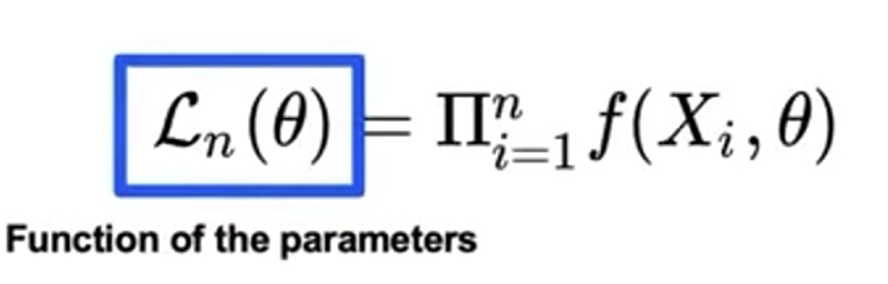

The meaning of the method : Find the set of parameters (e.g., mu (mean), sigma (standard deviation)) that maximizes the probability of observing your entire raw dataset (making it the most likely scenario)

## COMMONLY USED DISTRIBUTIONS



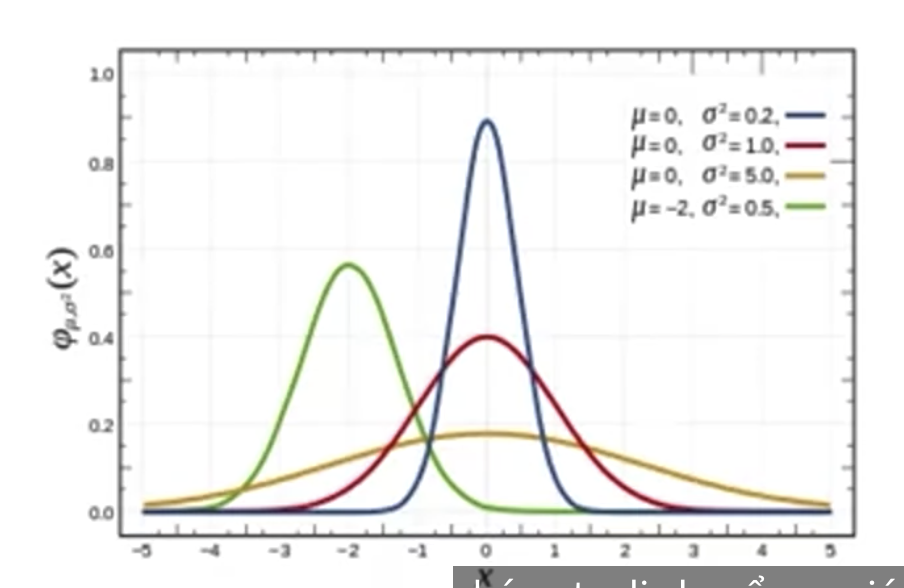

GAUSSIAN / NORMAL

$\mu$ đóng vai trò "cầm" đồ thị kéo sang trái hoặc phải, còn $\sigma^2$ đóng vai trò "bóp" đồ thị nhọn lên hay "đè" đồ thị bẹp xuống.

$\mu$ kì vọng (mean) 

Còn $\sigma^2$ là phương sai  

## LOG - NORNAL

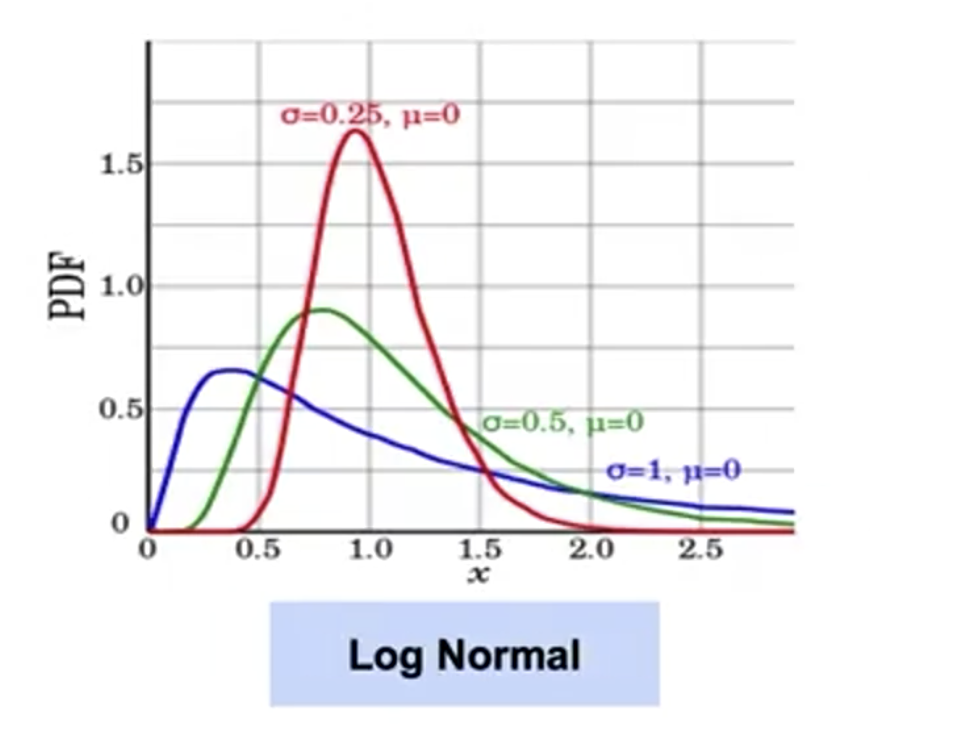

How the Parameter Controls the Shape: All three curves (red, green, and blue) are set to the same mean (expected value) of $\mu = 0$

The difference in their shapes is entirely determined by the standard deviation ($\sigma$):

Red curve ($\sigma = 0.25$): When $\sigma$ is small, the data is less spread out and clusters tightly together. This creates a very tall, sharp peak and a short right tail

Green curve ($\sigma = 0.5$): As $\sigma$ increases, the peak gradually drops and the graph begins to widen

Blue curve ($\sigma = 1$): When $\sigma$ is at its largest, the peak is pushed down to its lowest point, and the right tail stretches far out along the $x$-axis. A longer tail means there is a higher probability of extreme values (large outliers) occurring.

The graph has the correlation between PDF and x_value

## Exponential 

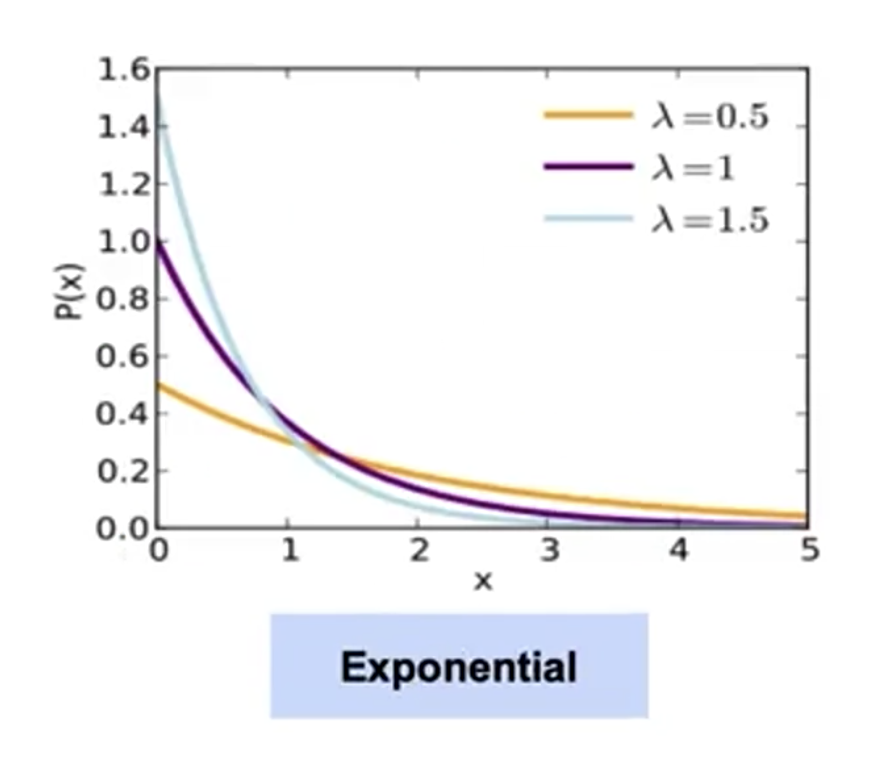